# EPI Index Comparison
## Comprehensive Analysis of Emotion Polarity Index Variants

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modules.finance.exploration import *

plt.rcParams.update({"font.size": 14})
pd.set_option("display.max_columns", None)

In [2]:
# Configuration
DATA_DIR = "./data/"
OUTPUT_DIR = "./data/fm_prelim/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Files
FINANCIAL_PANEL_FILE = DATA_DIR + "financial_returns_and_controls.parquet"
EPI_DATA_FILE = DATA_DIR + "epi_data_all_lownull.json"

# Parameters
ROLLING_WINDOW = 14
MAX_LAG = 10
IC = 'aic'
ALPHA = 0.05
CORRECTION_METHOD = 'fdr_bh'

print("✓ Configuration complete")

✓ Configuration complete


## Load Data

In [3]:
# Load data
df_returns = pd.read_parquet(FINANCIAL_PANEL_FILE)
df_epi = pd.read_json(EPI_DATA_FILE)
df_epi['date'] = pd.to_datetime(df_epi['date'])
df_epi = df_epi.set_index('date')

df = df_returns.join(df_epi, how='left')
df[df_epi.columns] = df[df_epi.columns].fillna(0)

print(f"Data loaded: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Data loaded: (108, 115)
Date range: 2025-01-01 00:00:00 to 2025-05-30 00:00:00


In [4]:
# Find EPI variants
epi_variants = find_index_variants(df.columns, 'epi')
ASSET_COLS = ['r_btc', 'r_gold', 'r_spx']
ASSET_COLS = [c for c in ASSET_COLS if c in df.columns]

print(f"\nEPI variants found: {len(epi_variants)}")
for i, var in enumerate(epi_variants, 1):
    print(f"  {i}. {var}")
print(f"\nAssets: {ASSET_COLS}")


EPI variants found: 4
  1. epi
  2. epi_engweighted
  3. epi_topicweighted
  4. epi_engweighted_topicweighted

Assets: ['r_btc', 'r_gold', 'r_spx']


## Test Framework Functions

\n======================================================================
TEST 1: Descriptive Statistics

EPI Variants


,count,mean,std,min,25%,50%,75%,max,skew,kurt,missing_pct,zero_pct
epi,108.0,0.040306,0.048838,0.0,0.014517,0.026350,0.044693,0.249999,2.643250,7.475488,0.0,1.851852
epi_engweighted,108.0,0.039631,0.048020,0.0,0.015274,0.025227,0.042855,0.250000,2.748598,8.018756,0.0,1.851852
epi_engweighted_topicweighted,108.0,0.010246,0.013119,0.0,0.001026,0.005042,0.016353,0.069945,1.932863,4.741900,0.0,10.185185
epi_topicweighted,108.0,0.027039,0.022467,0.0,0.012275,0.023233,0.037419,0.121523,1.266120,2.403857,0.0,8.333333



Correlation between variants:


,epi,epi_engweighted,epi_topicweighted,epi_engweighted_topicweighted
epi,1.000000,0.992164,0.322115,0.195305
epi_engweighted,0.992164,1.000000,0.290670,0.199292
epi_topicweighted,0.322115,0.290670,1.000000,0.176112
epi_engweighted_topicweighted,0.195305,0.199292,0.176112,1.000000


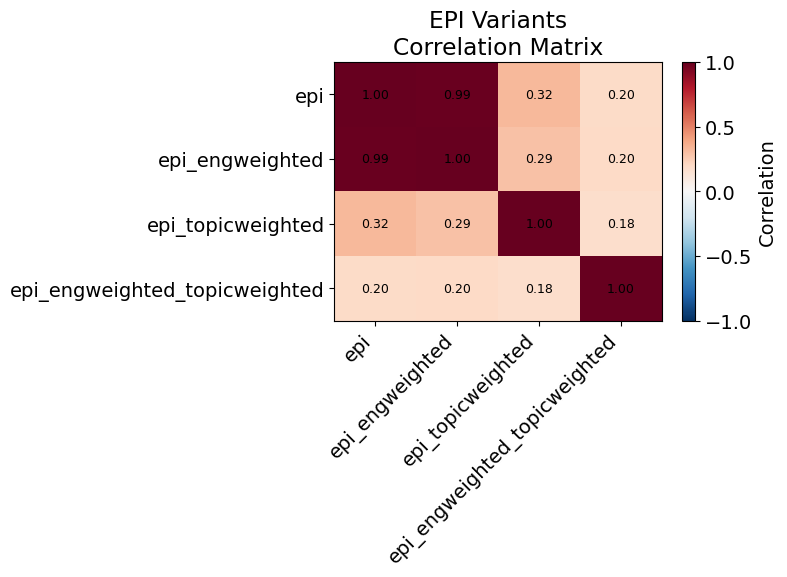

In [5]:
# Test: Descriptive statistics
print("\\n" + "="*70)
print("TEST 1: Descriptive Statistics")
print("="*70)
stats = compare_index_variants_descriptive(df, epi_variants, 'EPI Variants')


TEST 2: Time Series Visualization


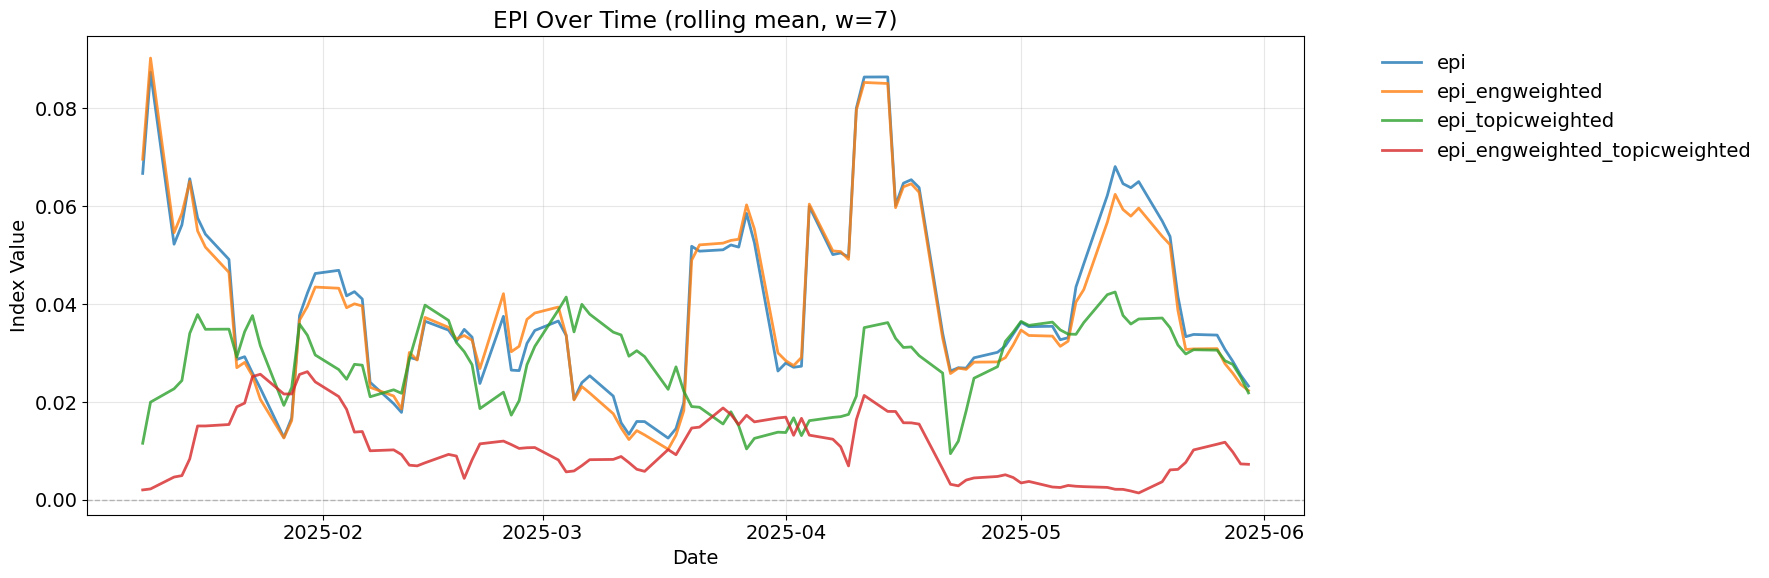

In [6]:
# Test: Time series visualization
print("\n" + "="*70)
print("TEST 2: Time Series Visualization")
print("="*70)
compare_index_variants_timeseries(df, epi_variants, 'EPI Over Time', rolling_window=7)


TEST 3: Rolling Correlations with Assets


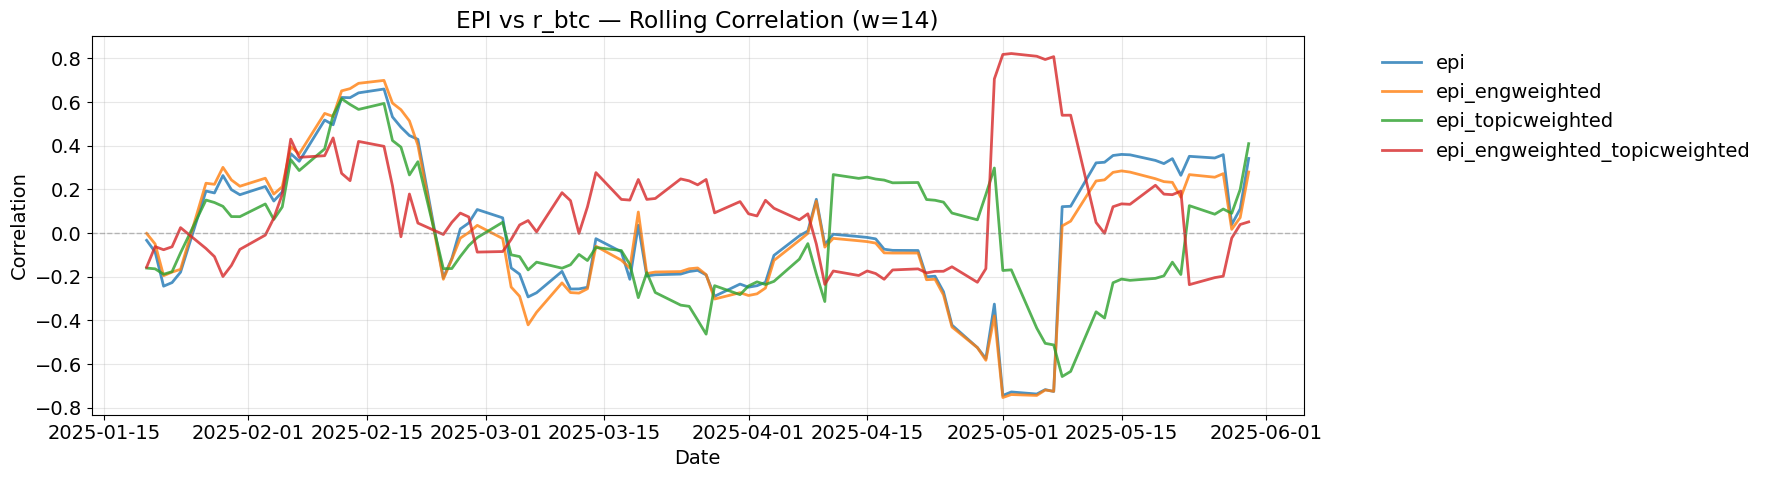

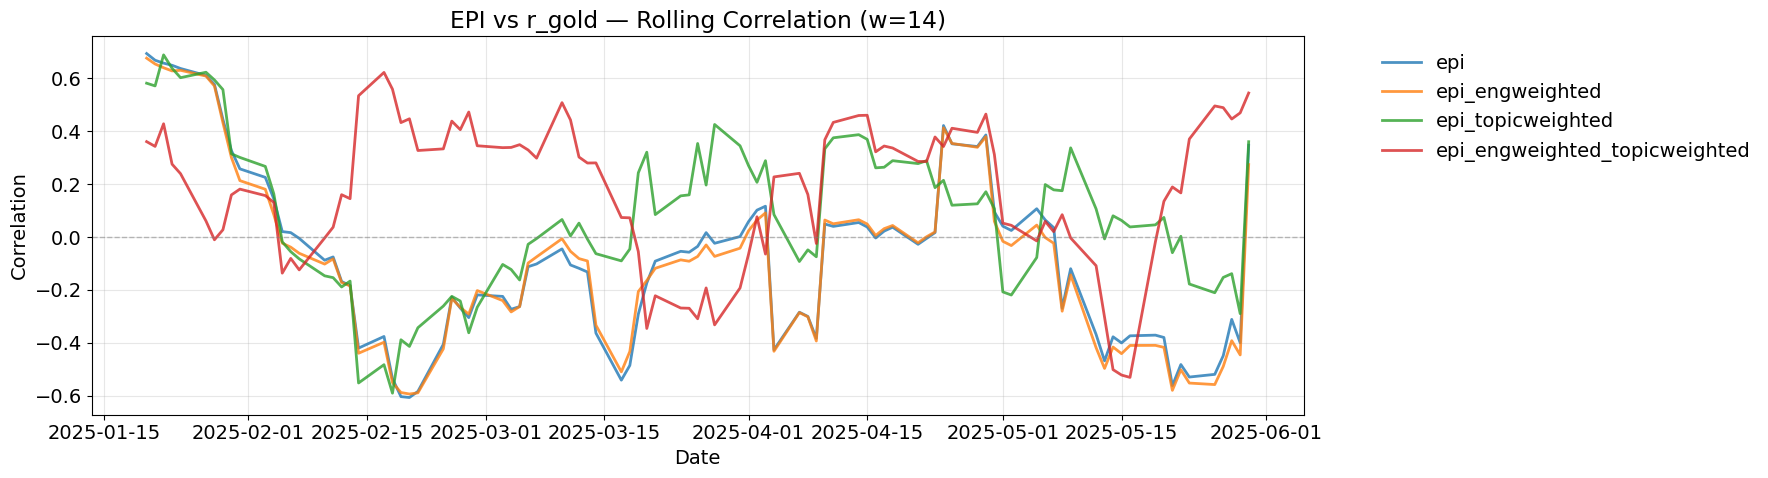

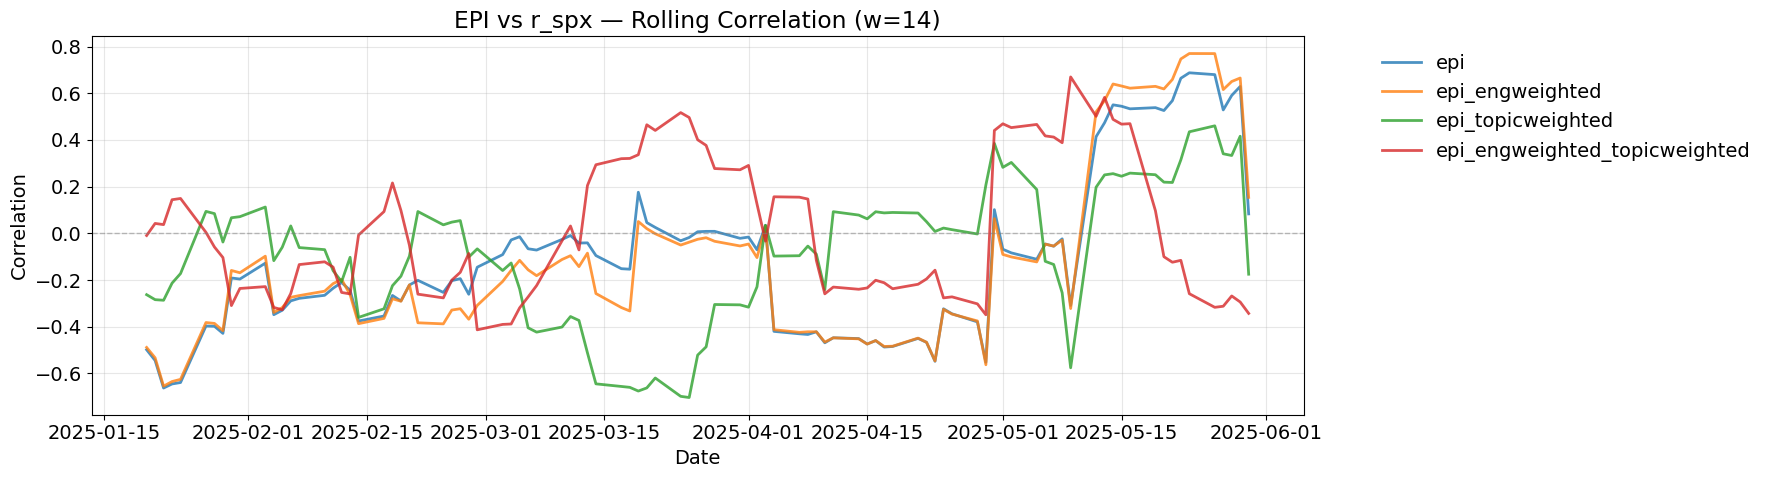

In [8]:
# Test: Rolling correlations with assets
print("\n" + "="*70)
print("TEST 3: Rolling Correlations with Assets")
print("="*70)
compare_variants_vs_assets(df, epi_variants, ASSET_COLS, 'EPI', rolling_window=ROLLING_WINDOW)

## Granger Causality Tests

Test if EPI variants Granger-cause asset returns using:
- AIC/BIC for optimal lag selection
- Benjamini-Hochberg FDR correction for multiple testing


TEST 4: Granger Causality Tests

GRANGER CAUSALITY TESTS: EPI Variants
Running 12 Granger causality tests...
  Index → Asset causality
  Max lag: 10, IC: AIC
  Multiple testing correction: fdr_bh

✓ Tests complete
  Significant relationships (corrected α=0.05): 0 of 12
  Uncorrected significant (α=0.05): 0

P-values (at optimal lag):


asset,r_btc,r_gold,r_spx
index,,,
epi,0.894564,0.373330,0.485232
epi_engweighted,0.828526,0.455216,0.461772
epi_engweighted_topicweighted,0.774424,0.777714,0.532398
epi_topicweighted,0.233982,0.283188,0.053011



Corrected p-values (fdr_bh):


asset,r_btc,r_gold,r_spx
index,,,
epi,0.894564,0.798597,0.798597
epi_engweighted,0.894564,0.798597,0.798597
epi_engweighted_topicweighted,0.894564,0.894564,0.798597
epi_topicweighted,0.798597,0.798597,0.636129



Significant relationships (α=0.05, corrected):


asset,r_btc,r_gold,r_spx
index,,,
epi,0,0,0
epi_engweighted,0,0,0
epi_engweighted_topicweighted,0,0,0
epi_topicweighted,0,0,0


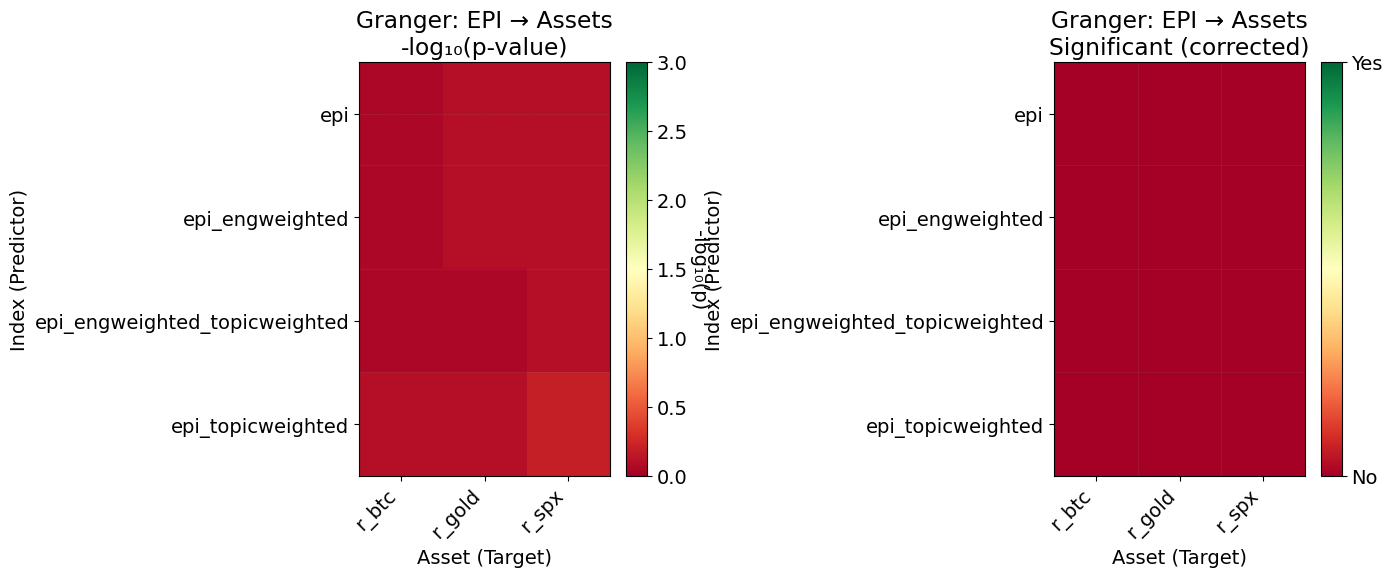

In [7]:
print("\n" + "="*70)
print("TEST 4: Granger Causality Tests")
print("="*70)

pval_mat, pval_corrected, sig_mat = granger_comparison_variants(
    df, epi_variants, ASSET_COLS,
    maxlag=MAX_LAG, ic=IC, alpha=ALPHA, correction_method=CORRECTION_METHOD
)

In [9]:
# Variant performance summary
print("\n" + "="*70)
print("TEST 5: Performance Summary")
print("="*70)
performance = summarize_variant_performance(pval_mat, sig_mat, epi_variants)


TEST 5: Performance Summary

VARIANT PERFORMANCE SUMMARY


,variant,n_significant,mean_pvalue,min_pvalue
0,epi,0,0.584376,0.373330
1,epi_engweighted,0,0.581838,0.455216
2,epi_topicweighted,0,0.190060,0.053011
3,epi_engweighted_topicweighted,0,0.694846,0.532398


In [10]:
# Save results
pval_mat.to_csv(os.path.join(OUTPUT_DIR, "epi_granger_pvalues.csv"))
pval_corrected.to_csv(os.path.join(OUTPUT_DIR, "epi_granger_pvalues_corrected.csv"))
sig_mat.to_csv(os.path.join(OUTPUT_DIR, "epi_granger_significant.csv"))
performance.to_csv(os.path.join(OUTPUT_DIR, "epi_variant_performance.csv"), index=False)

print("\n✓ Results saved to:", OUTPUT_DIR)


✓ Results saved to: ./data/fm_prelim/


## Stationarity Tests

Check if series are stationary (required for valid Granger tests)

In [11]:
print("\n" + "="*70)
print("TEST 6: Stationarity Tests (ADF & KPSS)")
print("="*70)

stationarity_results = []

for var in epi_variants:
    if var in df.columns:
        adf = adf_test(df[var])
        kpss_result = kpss_test(df[var])
        
        stationarity_results.append({
            'index': var,
            'adf_stat': adf['statistic'],
            'adf_pval': adf['pvalue'],
            'adf_stationary': '✓' if adf['is_stationary'] else '✗',
            'kpss_stat': kpss_result['statistic'],
            'kpss_pval': kpss_result['pvalue'],
            'kpss_stationary': '✓' if kpss_result['is_stationary'] else '✗'
        })

stationarity_df = pd.DataFrame(stationarity_results)
display(stationarity_df)

print("\nInterpretation:")
print("  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)")
print("  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)")


TEST 6: Stationarity Tests (ADF & KPSS)


/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series_clean, regression=regression, nlags=nlags)
/Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/modules/finance/exploration/statistical_tests.py:98: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value ret

,index,adf_stat,adf_pval,adf_stationary,kpss_stat,kpss_pval,kpss_stationary
0,epi,-10.978233,7.573623e-20,✓,0.091308,0.100000,✓
1,epi_engweighted,-10.908584,1.111780e-19,✓,0.093100,0.100000,✓
2,epi_topicweighted,-9.267113,1.357580e-15,✓,0.085694,0.100000,✓
3,epi_engweighted_topicweighted,-3.297614,1.498547e-02,✓,0.355169,0.096479,✓



Interpretation:
  ADF: H0=non-stationary. ✓ if p<0.05 (reject H0, series is stationary)
  KPSS: H0=stationary. ✓ if p>0.05 (fail to reject H0, series is stationary)


## Bidirectional Granger Tests

Test causality in both directions for best performing variant

In [12]:
print("\n" + "="*70)
print("TEST 7: Bidirectional Granger Tests")
print("="*70)

# Use best performing variant
best_variant = performance.iloc[0]['variant']
print(f"\nBest variant: {best_variant}\n")

for asset in ASSET_COLS:
    print(f"\n{best_variant} ↔ {asset}:")
    print("-" * 70)
    result = bidirectional_granger_test(df, best_variant, asset, maxlag=MAX_LAG, ic=IC)
    display(result)


TEST 7: Bidirectional Granger Tests

Best variant: epi


epi ↔ r_btc:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi → r_btc,1,0.894564,0.038332,True,False
1,r_btc → epi,2,0.126135,0.046469,True,False



epi ↔ r_gold:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi → r_gold,1,0.373330,0.197960,False,False
1,r_gold → epi,2,0.989347,0.881911,False,False



epi ↔ r_spx:
----------------------------------------------------------------------


,direction,optimal_lag,pvalue_at_optimal,min_pvalue,granger_causes,granger_causes_at_optimal
0,epi → r_spx,1,0.485232,0.029649,True,False
1,r_spx → epi,2,0.067628,0.051148,False,False


## Event Window Analysis

How do EPI variants behave during major tariff events?

In [13]:
EVENT_WINDOWS = [
    ("Initial Tariff Announcements", "2025-01-20", "2025-01-26"),
    ("Tariffs Postponed", "2025-03-04", "2025-03-06"),
    ("China Retaliation & US Tariffs", "2025-03-10", "2025-03-13"),
    ("Global Tariffs", "2025-04-02", "2025-04-06"),
    ("US-China Tariff Threats", "2025-04-09", "2025-04-12"),
    ("Tariffs Relaxed", "2025-04-27", "2025-05-04"),
    ("Trade Deals", "2025-05-05", "2025-05-14"),
    ("Apple Tariff Threat", "2025-05-20", "2025-05-25"),
]

print("\n" + "="*70)
print("TEST 8: Event Window Analysis")
print("="*70)

event_comparison = event_window_comparison(df, epi_variants, EVENT_WINDOWS, pre_days=7, post_days=7)

# Display delta rows only (more compact)
delta_rows = event_comparison[event_comparison['phase'].str.contains('Δ', na=False)]
display(delta_rows)

# Save
event_comparison.to_csv(os.path.join(OUTPUT_DIR, "epi_event_windows.csv"), index=False)
print("\n✓ Event analysis saved")


TEST 8: Event Window Analysis


,event,phase,n,epi_mean,epi_std,epi_engweighted_mean,epi_engweighted_std,epi_topicweighted_mean,epi_topicweighted_std,epi_engweighted_topicweighted_mean,epi_engweighted_topicweighted_std
3,Initial Tariff Announcements,Δ during-pre,NaN,-0.025504,NaN,-0.022020,NaN,-0.010286,NaN,0.002783,NaN
4,Initial Tariff Announcements,Δ post-during,NaN,0.039100,NaN,0.036982,NaN,0.002831,NaN,-0.003343,NaN
8,Tariffs Postponed,Δ during-pre,NaN,-0.009008,NaN,-0.007898,NaN,-0.003258,NaN,0.006428,NaN
9,Tariffs Postponed,Δ post-during,NaN,-0.002630,NaN,-0.004053,NaN,-0.012013,NaN,-0.005556,NaN
13,China Retaliation & US Tariffs,Δ during-pre,NaN,-0.004383,NaN,-0.001413,NaN,-0.006464,NaN,-0.009531,NaN
14,China Retaliation & US Tariffs,Δ post-during,NaN,0.053957,NaN,0.051241,NaN,-0.011951,NaN,0.018600,NaN
18,Global Tariffs,Δ during-pre,NaN,0.060793,NaN,0.056215,NaN,0.005095,NaN,-0.009003,NaN
19,Global Tariffs,Δ post-during,NaN,-0.020881,NaN,-0.019144,NaN,0.026032,NaN,0.015795,NaN
23,US-China Tariff Threats,Δ during-pre,NaN,0.047263,NaN,0.046610,NaN,0.043938,NaN,0.027236,NaN
24,US-China Tariff Threats,Δ post-during,NaN,-0.074815,NaN,-0.073750,NaN,-0.054202,NaN,-0.035344,NaN



✓ Event analysis saved


## Summary

Comprehensive comparison of EPI variants

In [14]:
print("\n" + "="*70)
print("EPI VARIANT COMPARISON - SUMMARY")
print("="*70)

print("\n1. VARIANTS TESTED:")
for i, var in enumerate(epi_variants, 1):
    print(f"   {i}. {var}")

print("\n2. CORRELATION WITH ASSETS (mean absolute):")
for var in epi_variants:
    if var in df.columns:
        mean_abs_corr = df[[var] + ASSET_COLS].corr().loc[var, ASSET_COLS].abs().mean()
        print(f"   {var:35s}: {mean_abs_corr:.4f}")

print("\n3. GRANGER CAUSALITY (significant relationships after FDR):")
for _, row in performance.iterrows():
    print(f"   {row['variant']:35s}: {int(row['n_significant'])} significant")

print("\n4. BEST PERFORMING VARIANT:")
print(f"   {best_variant}")
print(f"   - Significant Granger relationships: {int(performance.iloc[0]['n_significant'])}/{len(ASSET_COLS)}")
print(f"   - Mean p-value: {performance.iloc[0]['mean_pvalue']:.4f}")

print("\n5. KEY INSIGHTS:")
corr_base_eng = df[['epi', 'epi_engweighted']].corr().iloc[0, 1]
print(f"   - Base EPI and engagement-weighted highly correlated (r={corr_base_eng:.3f})")
print(f"   - Topic-weighted variants show distinct patterns")
print(f"   - FDR correction substantially reduces false positives")

print("\n" + "="*70)
print("✓ FRAMEWORK TEST COMPLETE")
print("="*70)
print("\nAll modules working correctly:")
print("  ✓ statistical_tests.py - Granger, ADF, KPSS, FDR correction")
print("  ✓ index_analysis.py - Variant comparison, event windows")
print("  ✓ Data pipeline - Loading, merging, analysis")
print("\nReady to create analyses for other indices (signed_epi, ccd, surprise, etc.)")


EPI VARIANT COMPARISON - SUMMARY

1. VARIANTS TESTED:
   1. epi
   2. epi_engweighted
   3. epi_topicweighted
   4. epi_engweighted_topicweighted

2. CORRELATION WITH ASSETS (mean absolute):
   epi                                : 0.0871
   epi_engweighted                    : 0.0915
   epi_topicweighted                  : 0.0412
   epi_engweighted_topicweighted      : 0.1180

3. GRANGER CAUSALITY (significant relationships after FDR):
   epi                                : 0 significant
   epi_engweighted                    : 0 significant
   epi_topicweighted                  : 0 significant
   epi_engweighted_topicweighted      : 0 significant

4. BEST PERFORMING VARIANT:
   epi
   - Significant Granger relationships: 0/3
   - Mean p-value: 0.5844

5. KEY INSIGHTS:
   - Base EPI and engagement-weighted highly correlated (r=0.992)
   - Topic-weighted variants show distinct patterns
   - FDR correction substantially reduces false positives

✓ FRAMEWORK TEST COMPLETE

All modules wor